# 09_02.Model Comparison(분류)

## 1.기본 package 설정

In [ ]:
# 그래프에서 한글 폰트 인식하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 가져오기
import pandas as pd # csv -> dataframe으로 전환

## 3.데이터 전처리
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline                    # 불균형데이터 처리를 위한 pipeline 수정
# from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# 4. 훈련/검증용 데이터 분리
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE                  # 불균형데이터 처리로 수정

## 5.모델구축
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델
from sklearn.neural_network import MLPClassifier # 다층인공신경망(분류)
from sklearn.svm import SVC # 서포트 벡터 머신(SVM)(분류)
from sklearn.tree import DecisionTreeClassifier, plot_tree # 결정 트리(분류)
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트(분류)
from xgboost import XGBClassifier # XG부스팅(분류)
from sklearn.neighbors import KNeighborsClassifier # K-최근접 이웃(분류)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # 판별분석(분류)
from sklearn.naive_bayes import GaussianNB # 나이브 베이지안(분류)(실수형)

## 6.모델검정
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report # 정오분류표
from sklearn.metrics import ConfusionMatrixDisplay # 그래프 그리기기
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score  # 정확도, 민감도 등
from sklearn.metrics import roc_curve, auc # ROC 곡선 그리기

# 7.최적화
from sklearn.model_selection import GridSearchCV # 하이퍼파라미터 튜닝

## 2.데이터 불러오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2.2 데이터 프레임으로 저장
- 원본데이터(csv)를 dataframe 형태로 가져오기(pandas)

In [ ]:
breast_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/유방암진단.csv', encoding="cp949")
breast_df.head()

,id,진단,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,1,1,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,2,1,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,3,1,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,4,0,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,5,0,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


### 2.3 자료구조 살펴보기

In [ ]:
breast_df.shape

In [ ]:
breast_df.info()

In [ ]:
breast_df.columns

## 3.데이터 전처리

### 3.1 필요없는 변수 제거

In [ ]:
breast_df = breast_df.drop (['id'], axis=1)
breast_df.head()

,진단,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,1,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,1,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,1,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,0,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,0,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


### 3.2 범주형 변수 처리
- 가변수 처리시 문자로 처리를 해야 변수명 구분이 쉬움

In [ ]:
breast_df['진단'] = breast_df['진단'].replace ([1,0], ['악성','양성'])  # 중요한 변수를 앞으로 변경

breast_df.head()

,진단,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,악성,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,악성,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,악성,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,양성,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,양성,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


In [ ]:
breast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   진단      565 non-null    object 
 1   반지름     565 non-null    float64
 2   질감      565 non-null    float64
 3   주변부     565 non-null    float64
 4   크기      565 non-null    float64
 5   평활도     565 non-null    float64
 6   조밀성     565 non-null    float64
 7   오목      565 non-null    float64
 8   대칭      565 non-null    float64
 9   프랙탈     565 non-null    float64
dtypes: float64(9), object(1)
memory usage: 44.3+ KB


## 4.데이터 탐색

### 4.1 EDA 데이터 탐색

In [ ]:
# 수치형 변수
breast_df.describe().round(2).T

In [ ]:
# 그룹별 분석
breast_df.groupby('진단').mean()

In [ ]:
# 범주형 변수
# lecture_df.columns
categorical_features=['진단']

for col in categorical_features:
    cat = breast_df[col].value_counts()
    print(cat)

### 4.2 그래프 그리기

In [ ]:
# 한글 폰트 인식
plt.rc('font', family='NanumBarunGothic')

In [ ]:
# 수치형 변수
g = sns.pairplot(breast_df,
                 hue="진단",
                 markers=["o", "s"])

In [ ]:
# 범주형 변수
for col in categorical_features:
    sns.countplot(x=col, data = breast_df)
    plt.show()

### 4.3 base accuracy


In [ ]:
# base accuracy
breast_df['진단'].value_counts()

In [ ]:
breast_df['진단'].value_counts()/breast_df.shape[0]

## 5.훈련/테스트용 데이터 분할


### 5.1 data와 target으로 분리
- data: X, target: y 로 분리

- X 추출


In [ ]:
# X 추출법(3): y값만 제거
X = breast_df.drop (['진단'], axis=1)
X.head()

,반지름,질감,주변부,크기,평활도,조밀성,오목,대칭,프랙탈
0,18.0,10.4,122.8,1001.0,0.118,0.278,0.300,0.242,0.079
1,20.6,17.8,132.9,1326.0,0.085,0.079,0.087,0.181,0.057
2,19.7,21.3,130.0,1203.0,0.110,0.160,0.197,0.207,0.060
3,13.5,14.4,87.5,566.3,0.098,0.081,0.067,0.189,0.058
4,13.1,15.7,85.6,520.0,0.108,0.127,0.046,0.197,0.068


- target(y) 추출
- y 값을 series에서 배열로 변환

In [ ]:
y = breast_df['진단']
y.head()

0    악성
1    악성
2    악성
3    양성
4    양성
Name: 진단, dtype: object

In [ ]:
# y 값을 배열로 변환
# 악성 -> 0, 양성 -> 1로 변경됨

class_le = LabelEncoder()
y = class_le.fit_transform(y)
y

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,

### 5.2 훈련용 및 테스트용 데이터 분할
- test_size: 검증데이터 30%
- random_state : random seed 번호 = 1
- stratify : y(클래스)의 비율에 따라 분할(분류모형일때 사용)

In [ ]:
# \ 이후에 space 없어야 함
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 1)

In [ ]:
X_train.info()

In [ ]:
y_train.info()

In [ ]:
X_test.info()

In [ ]:
y_test.info()

## 6.pipeline으로 데이터 전처리
https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html
- R에서 recipe
- 범주형 변수: OneHotEncoder
- 수치형 변수:
- 선형모델은 StandardScaler 로 표준화
- tree형 모델은 데이터 원형 사용

### 6.1 preprocess 세팅(linear형 모델)

In [ ]:
# from imblearn.pipeline import Pipeline
# 불균형데이터 처리를 위해 from sklearn.pipeline-> from imblearn.pipeline

In [ ]:
# pipeline으로 세팅
# 수치형 변수(y는 제외)
numeric_features = ['반지름', '질감', '주변부', '크기', '평활도', '조밀성', '오목', '대칭', '프랙탈']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')), # 누락된 값은 중앙값으로 처리
        ('scaler', StandardScaler())
    ]
)

# 범주형 변수(y는 제외)
categorical_features=[]

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant',
                                  fill_value='missing')),  # 누락된 값은 missing으로 상수 처리
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessor로 데이터 변환 세팅
preprocessor_line = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
preprocessor_line

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['반지름', '질감', '주변부', '크기', '평활도', '조밀성', '오목',
                                  '대칭', '프랙탈']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])

In [ ]:
pd.DataFrame(preprocessor_line.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8
0,-0.597833,-1.386208,-0.603885,-0.619406,0.957570,-0.296489,-0.674520,-0.580865,0.461349
1,-0.570152,0.147031,-0.535571,-0.597450,0.957570,0.189216,-0.110879,1.118156,0.893521
2,-0.708556,-0.062047,-0.744530,-0.693053,-0.584837,-1.015331,-0.956340,0.453322,-0.258939
3,-0.874640,-0.131740,-0.784714,-0.851741,1.798883,2.132032,1.003591,1.413638,2.478153
4,-0.154942,-0.154971,-0.165875,-0.269791,0.186367,0.033790,-0.469560,-0.396189,0.749464


### 6.2 preprocess 세팅(tree형 모델)

In [ ]:
# pipeline으로 세팅
# 수치형 변수(y는 제외)
numeric_features = ['반지름', '질감', '주변부', '크기', '평활도', '조밀성', '오목', '대칭', '프랙탈']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')), # 누락된 값은 중앙값으로 처리
        #('scaler', StandardScaler())
    ]
)

# 범주형 변수(y는 제외)
categorical_features=[]

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant',
                                  fill_value='missing')),  # 누락된 값은 missing으로 상수 처리
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessor로 데이터 변환 세팅
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
preprocessor_tree

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['반지름', '질감', '주변부', '크기', '평활도', '조밀성', '오목',
                                  '대칭', '프랙탈']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 [])])

In [ ]:
pd.DataFrame(preprocessor_tree.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8
0,12.1,13.4,77.8,445.2,0.110,0.090,0.038,0.166,0.066
1,12.2,20.0,79.5,453.1,0.110,0.115,0.082,0.212,0.069
2,11.7,19.1,74.3,418.7,0.088,0.053,0.016,0.194,0.061
3,11.1,18.8,73.3,361.6,0.122,0.215,0.169,0.220,0.080
4,13.7,18.7,88.7,571.0,0.099,0.107,0.054,0.171,0.068


## 7.모델만들기 (모델 설정)
- R에서 workflow
- 예측모델: 000_reg
- 분류모델: 000_clf

### 7.1 pipeline으로 모델 연결

In [ ]:
# linear형 모델

lr_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("lr_clf", LogisticRegression())                   # lr_reg --> lr_clf
    ]
)

mlp_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("mlp_clf", MLPClassifier())                   # mlp_reg --> mlp_clf
    ]
)

svc_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ('smote', SMOTE(sampling_strategy = 0.75)),
        ("svc_clf", SVC(probability = True))               # svc_reg --> svc_clf, probability=True
    ]
)

knn_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("knn_clf", KNeighborsClassifier())                                 # knn_reg --> knn_clf
    ]
)

da_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("da_clf", LinearDiscriminantAnalysis())                                 # da_reg --> da_clf
    ]
)

nb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_line),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("nb_clf", GaussianNB())
    ]
)

# tree형 모델

dt_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("dt_clf", DecisionTreeClassifier())                                 # dt_reg --> dt_clf
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("rf_clf", RandomForestClassifier())                                 # rf_reg --> rf_clf
    ]
)

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ('smote', SMOTE(sampling_strategy=0.75)),
        ("xgb_clf", XGBClassifier(learning_rate=0.1))      # learning_rate=0.1
    ]
)

### 7.2 하이퍼파라미터 세팅
- 그리드 서치를 사용한 머신 러닝 모델 세부 튜닝
- 기계학습 모델의 성능을 결정하는 하이퍼 파라미터 튜닝

In [ ]:
# linear형 모델

lr_grid = {
    'lr_clf__C': np.logspace(-5, -1, 5),      # 정규화 강도의 역수 [1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01]
}

mlp_grid = {
    'mlp_clf__hidden_layer_sizes': np.arange(2, 11, 2),    # 1개 layer로 세팅 [ 2,  4,  6,  8, 10]
    'mlp_clf__alpha': np.logspace(-5, -1, 5),              # 정규화 강도의 역수
}

svc_grid = {
    "svc_clf__kernel" : ["rbf", "linear"] ,
    'svc_clf__C': [0.1, 1, 10, 100, 1000],
    'svc_clf__gamma': [1, 0.1, 0.01, 0.001],
}

knn_grid = {
    'knn_clf__n_neighbors' : [3, 5, 7, 9],
    'knn_clf__weights' : ['uniform','distance'],
    'knn_clf__metric' : ['minkowski','euclidean','manhattan']
}

da_grid = {
    'da_clf__solver' : ['svd','lsqr','eigen'],
}

nb_grid = {
    'nb_clf__var_smoothing':np.logspace(-5,-1,5) ,     # [1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01]
}

# tree형 모델

dt_grid = {
    "dt_clf__ccp_alpha" :np.logspace(-5,-3,3) ,     # [1.e-05, 1.e-04, 1.e-03]
    'dt_clf__max_depth': [1, 3, 5, 7],
    'dt_clf__min_samples_leaf': [10, 30, 50],
}

rf_grid = {
    "rf_clf__ccp_alpha" :np.logspace(-5,-3,3) ,     # [1.e-05, 1.e-04, 1.e-03]
    'rf_clf__n_estimators' : [10, 50, 100],
    'rf_clf__max_depth' : [1, 5, 9],
}

xgb_grid = {
    'xgb_clf__n_estimators' : [10, 50, 100],
    'xgb_clf__gamma': [1, 5, 10],             # gain 값이 gamma 이상일 경우 자식 노드를 생성
    'xgb_clf__subsample': [0.25, 0.5, 1.0],   # 각각의 스탭마다 사용할 샘플의 비율 [0~1]
}

### 7.3 하이퍼파라미터 그리드 만들기

In [ ]:
pipe = [lr_pipe, mlp_pipe, svc_pipe, knn_pipe, da_pipe, nb_pipe, dt_pipe, rf_pipe, xgb_pipe]

grids = [lr_grid, mlp_grid, svc_grid, knn_grid, da_grid, nb_grid, dt_grid, rf_grid, xgb_grid]

models = {
    0:'lr_gs',
    1:'mlp_gs',
    2:'svc_gs',
    3:'knn_gs',
    4:'da_gs',
    5:'nb_gs',
    6:'dt_gs',
    7:'rf_gs',
    8:'xgb_gs'
}

## 8.모델 훈련(모델 학습)
- machine learning

### 8.1 모델 훈련하기(learning)

In [ ]:
gs_results = {}
gs_cv_results = {}
gs_best_params = {}
test_roc = {}

for idx , (grid , model) in enumerate(zip(grids , pipe)) :
    gs = GridSearchCV(estimator = model,         # model
                      param_grid = grid,         #grid
                      scoring='roc_auc',
                      cv = 10,                    # cv = 5
                      n_jobs = -1,
                      verbose = 10,              # 프로세스 진행사항 확인
                      return_train_score = True) # 훈련결과 저장
    gs_results[models.get(idx)] = gs.fit(X_train , y_train)
    gs_best_params[models.get(idx)] = gs.best_params_
    gs_cv_results[models.get(idx)] = gs.cv_results_
    y_pred = gs.predict(X_test)
    test_roc[models.get(idx)] = roc_auc_score(y_test, y_pred)
    print(models.get(idx), " 학습 완료")

print("학습이 완료되었습니다.")

Fitting 10 folds for each of 5 candidates, totalling 50 fits
lr_gs  학습 완료
Fitting 10 folds for each of 25 candidates, totalling 250 fits


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


mlp_gs  학습 완료
Fitting 10 folds for each of 40 candidates, totalling 400 fits
svc_gs  학습 완료
Fitting 10 folds for each of 24 candidates, totalling 240 fits
knn_gs  학습 완료
Fitting 10 folds for each of 3 candidates, totalling 30 fits
da_gs  학습 완료
Fitting 10 folds for each of 5 candidates, totalling 50 fits
nb_gs  학습 완료
Fitting 10 folds for each of 36 candidates, totalling 360 fits
dt_gs  학습 완료
Fitting 10 folds for each of 27 candidates, totalling 270 fits
rf_gs  학습 완료
Fitting 10 folds for each of 27 candidates, totalling 270 fits
xgb_gs  학습 완료
학습이 완료되었습니다.


In [ ]:
# 훈련모델 roc_acu값 정리
list_tmp_df = []

for i, model in enumerate(gs_cv_results):
    train_roc = pd.DataFrame({'model': model, 'roc_auc': gs_results[model].best_score_}, index = [0])
    list_tmp_df.append(train_roc)

train_roc = pd.concat(list_tmp_df, ignore_index = True)
train_roc = train_roc.sort_values(by=["roc_auc"], ascending= False)
train_roc

,model,roc_auc
2,svc_gs,0.996441
1,mlp_gs,0.992188
8,xgb_gs,0.991892
3,knn_gs,0.991354
0,lr_gs,0.991059
7,rf_gs,0.989922
4,da_gs,0.987691
5,nb_gs,0.982812
6,dt_gs,0.973941


In [ ]:
test_roc = pd.DataFrame([test_roc.keys() , test_roc.values()], index = ["model","roc_auc"]).T
test_roc.sort_values(["roc_auc"], ascending= False ,inplace=True)
test_roc

,model,roc_auc
6,dt_gs,0.946057
2,svc_gs,0.94517
8,xgb_gs,0.94517
1,mlp_gs,0.936623
7,rf_gs,0.930576
4,da_gs,0.925415
3,knn_gs,0.915256
5,nb_gs,0.903161
0,lr_gs,0.902274


In [ ]:
# 결과 통합
score_df = pd.merge(left = train_roc , right = test_roc, how = "inner", on = "model")
score_df

,model,roc_auc_x,roc_auc_y
0,svc_gs,0.996441,0.94517
1,mlp_gs,0.992188,0.936623
2,xgb_gs,0.991892,0.94517
3,knn_gs,0.991354,0.915256
4,lr_gs,0.991059,0.902274
5,rf_gs,0.989922,0.930576
6,da_gs,0.987691,0.925415
7,nb_gs,0.982812,0.903161
8,dt_gs,0.973941,0.946057


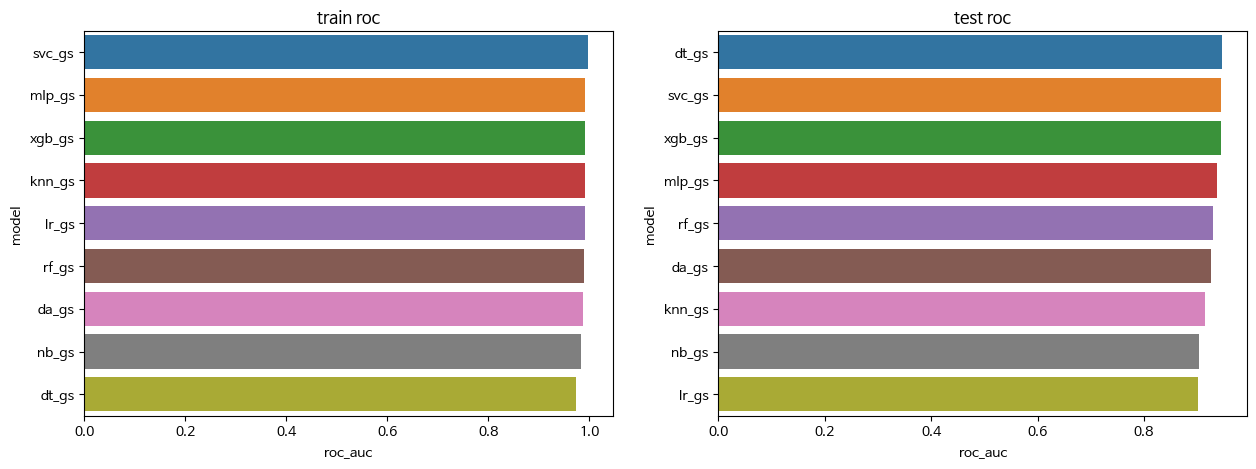

In [ ]:
# train, test r2 값 비교
plt.rc('font', family='NanumBarunGothic')

fig ,ax = plt.subplots(1, 2, figsize=(15, 5))
plt.subplot(1,2, 1)
plt.title("train roc")
sns.barplot(y="model", x="roc_auc", data = train_roc)
plt.subplot(1,2, 2)
plt.title("test roc")
sns.barplot(y="model", x="roc_auc", data = test_roc)
plt.show()

### 8.2 검증 곡선으로 Tuning 결과 확인
- 결과 표로 정리: https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html#sphx-glr-auto-examples-model-selection-plot-grid-search-stats-py
- 그래프로 정리: https://stackoverflow.com/questions/37161563/how-to-graph-grid-scores-from-gridsearchcv

In [ ]:
# 결과확인
gs_cv_results['svc_gs']

{'mean_fit_time': array([0.11477971, 0.04075468, 0.07220559, 0.04004745, 0.10496006,
        0.08161187, 0.20546229, 0.04090831, 0.07047029, 0.03329129,
        0.03357718, 0.04009471, 0.04008162, 0.04915028, 0.08627803,
        0.03508389, 0.09512675, 0.04697275, 0.04024341, 0.034887  ,
        0.02391906, 0.03861618, 0.03233874, 0.03503821, 0.06176045,
        0.16904058, 0.03000433, 0.141347  , 0.02914329, 0.15373878,
        0.02299104, 0.26650739, 0.13755093, 2.02596779, 0.04358706,
        2.92863057, 0.11812489, 2.80703177, 0.02556434, 1.3851366 ]),
 'std_fit_time': array([7.71864847e-03, 5.29237200e-03, 5.10812547e-03, 7.06010153e-03,
        2.95263009e-02, 2.29295815e-02, 4.56312576e-02, 6.47957313e-03,
        6.94527452e-03, 1.15519121e-02, 9.39520280e-03, 1.31229404e-02,
        1.47187556e-02, 2.24802744e-02, 2.52286105e-02, 1.35610661e-02,
        2.47937739e-02, 1.62084526e-02, 1.05854907e-02, 4.95710967e-03,
        2.46175620e-03, 5.83591371e-03, 7.07381399e-03, 5.343

In [ ]:
# 분석결과를 표로 정리
list_tmp_df = []

for i, model in enumerate(gs_cv_results):
    results_df = pd.DataFrame(gs_cv_results[model])                   # lr_gs.cv_results_ -> gs_cv_results[model]
    results_df = results_df.sort_values(by=["rank_test_score"])
    results_df = results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]
    list_tmp_df.append(results_df)                                   # 추가

results = pd.concat(list_tmp_df, ignore_index=True)
results = results.sort_values(by=["mean_test_score"], ascending = False)
results


,params,rank_test_score,mean_test_score,std_test_score
30,"{'svc_clf__C': 100, 'svc_clf__gamma': 0.01, 's...",1,0.996441,0.004072
31,"{'svc_clf__C': 1000, 'svc_clf__gamma': 0.01, '...",2,0.993976,0.005113
32,"{'svc_clf__C': 1, 'svc_clf__gamma': 0.1, 'svc_...",3,0.993437,0.007491
33,"{'svc_clf__C': 10, 'svc_clf__gamma': 0.01, 'sv...",4,0.992691,0.009272
34,"{'svc_clf__C': 10, 'svc_clf__gamma': 0.1, 'svc...",5,0.992309,0.008241
...,...,...,...,...
133,"{'dt_clf__ccp_alpha': 0.0001, 'dt_clf__max_dep...",31,0.876042,0.052285
134,"{'dt_clf__ccp_alpha': 1e-05, 'dt_clf__max_dept...",33,0.873542,0.054725
135,"{'dt_clf__ccp_alpha': 0.001, 'dt_clf__max_dept...",34,0.868542,0.052062
136,"{'dt_clf__ccp_alpha': 0.0001, 'dt_clf__max_dep...",35,0.866667,0.048930


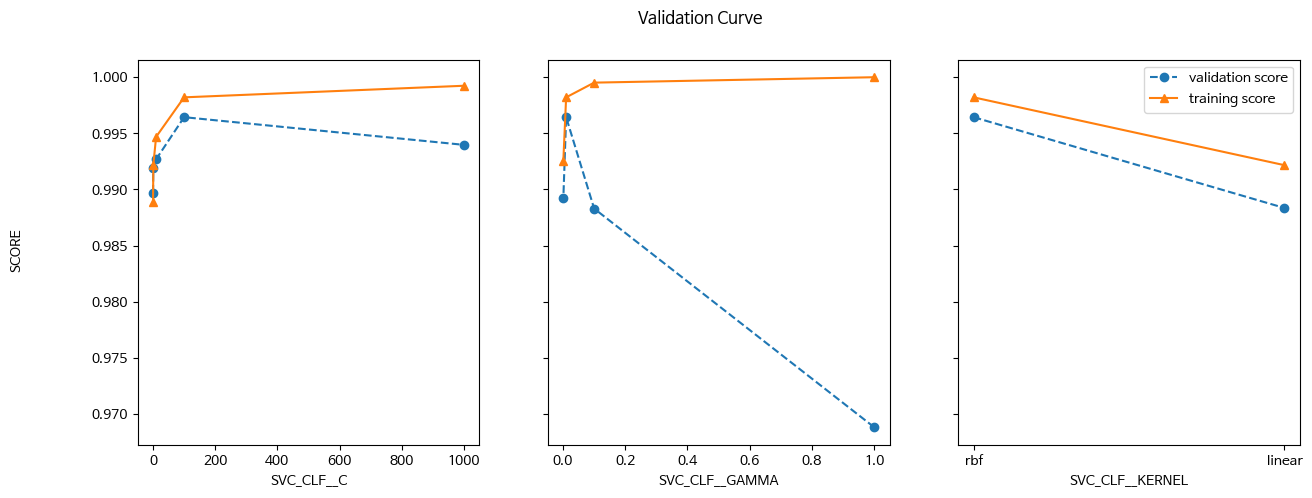

In [ ]:
# 튜닝결과 그래프
results = gs_results['svc_gs'].cv_results_                           # gs_results['svc_gs']
means_test = results['mean_test_score']
means_train = results['mean_train_score']

masks = []
masks_names = list(gs_results['svc_gs'].best_params_.keys())        # gs_results['svc_gs']
for p_k, p_v in gs_results['svc_gs'].best_params_.items():          # gs_results['svc_gs']
    masks.append(list(results['param_'+p_k].data==p_v))

params = gs_results['svc_gs'].param_grid                            # gs_results['svc_gs']

fig, ax = plt.subplots(1,len(params),
                       sharex='none',
                       sharey='all',
                       figsize=(15,5))
fig.suptitle('Validation Curve')
fig.text(0.04, 0.5, 'SCORE')

for i, p in enumerate(masks_names):
    m = np.stack(masks[:i] + masks[i+1:])
    best_parms_mask = m.all(axis=0)
    best_index = np.where(best_parms_mask)[0]
    x = np.array(params[p])
    y_1 = np.array(means_test[best_index])
    y_2 = np.array(means_train[best_index])
    ax[i].errorbar(x, y_1, linestyle='--', marker='o', label='validation score')
    ax[i].errorbar(x, y_2, linestyle='-', marker='^',label='training score' )
    ax[i].set_xlabel(p.upper())

plt.legend()
plt.show()

### 8.3 best 모델 설정

In [ ]:
# best 모델 파라미터 확인
print(gs_results['svc_gs'].best_score_)
print(gs_results['svc_gs'].best_params_)

0.9959027777777777
{'svc_clf__C': 100, 'svc_clf__gamma': 0.01, 'svc_clf__kernel': 'rbf'}


In [ ]:
# best 모델 파라미터를 최종모델로 훈련
best_clf = gs_results['svc_gs'].best_estimator_
best_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['반지름', '질감', '주변부', '크기',
                                                   '평활도', '조밀성', '오목', '대칭',
                                                   '프랙탈']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('smote', SMOTE(sampling_strategy=0.75)),
                ('svc_clf', SVC(C=100, gamma=0.01, probability=True))])

In [ ]:
print(best_clf['svc_clf'])

SVC(C=100, gamma=0.01, probability=True)


### 8.4 중요변수확인

In [ ]:
# 중요도 점수 계산
# linear만 계수 추출됨. rbf는 중요도 점수 출력 안됨

feature = best_clf['preprocessor'].get_feature_names_out()   # 수정
importances = best_clf["svc_clf"].coef_        # 수정
importances = importances.flatten()                           # flatten() - 다차원 array를 1차원 array로 변환
output = pd.DataFrame([feature , importances],
                      index = ["feature","importances"]).T
output.sort_values(["importances"],
                   ascending= False ,
                   inplace=True)

In [ ]:
# 그래프 그리기

plt.rc('font', family='NanumBarunGothic')

fig ,ax = plt.subplots(figsize=(10, 5))
sns.set(font_scale = 1)
ax = sns.barplot(y="feature", x="importances", data=output)
plt.show()

## 9.모델 test 및 검정

### 9.1 검증용 데이터로 예측
- predict (class로 표시)
- predict_proba (확률값으로 표시): 분류모델에서 사용

In [ ]:
y_pred = best_clf.predict_proba(X_test)
y_pred

array([[6.43450194e-03, 9.93565498e-01],
       [1.30055510e-09, 9.99999999e-01],
       [5.04609683e-08, 9.99999950e-01],
       [9.19846107e-06, 9.99990802e-01],
       [6.53415058e-02, 9.34658494e-01],
       [1.19692729e-06, 9.99998803e-01],
       [5.64196540e-03, 9.94358035e-01],
       [7.83790506e-01, 2.16209494e-01],
       [9.99989916e-01, 1.00836308e-05],
       [9.94990978e-01, 5.00902226e-03],
       [7.48649571e-03, 9.92513504e-01],
       [7.12184934e-03, 9.92878151e-01],
       [7.43232093e-02, 9.25676791e-01],
       [4.50430192e-02, 9.54956981e-01],
       [2.53608647e-02, 9.74639135e-01],
       [2.57269684e-01, 7.42730316e-01],
       [9.09660700e-02, 9.09033930e-01],
       [9.99941599e-01, 5.84008041e-05],
       [1.00806152e-02, 9.89919385e-01],
       [8.26805860e-08, 9.99999917e-01],
       [2.42152471e-02, 9.75784753e-01],
       [9.99865591e-01, 1.34409144e-04],
       [9.77675646e-01, 2.23243544e-02],
       [9.88869157e-01, 1.11308434e-02],
       [9.987030

In [ ]:
y_pred = best_clf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1])

### 9.2 정오분류표 검정

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels = best_clf.classes_)
cm

array([[ 49,   4],
       [  4, 113]])

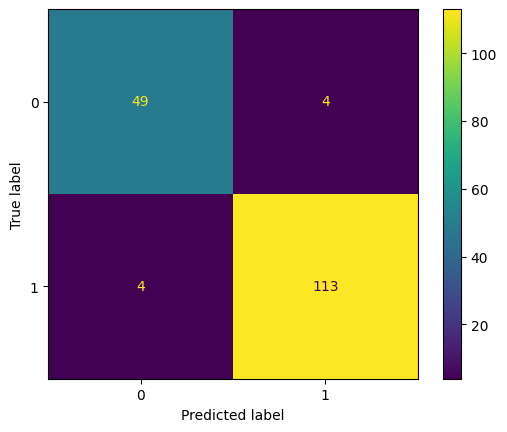

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_clf.classes_)
disp.plot()
plt.show()

### 9.3 모델 검정

In [ ]:
## 6.모델검정
#from sklearn.metrics import confusion_matrix, classification_report # 정오분류표
#from sklearn.metrics import ConfusionMatrixDisplay # 그래프 그리기기
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score  # 정확도, 민감도 등
#from sklearn.metrics import roc_curve, auc # ROC 곡선 그리기

In [ ]:
print('Classification Report')
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        53
           1       0.97      0.97      0.97       117

    accuracy                           0.95       170
   macro avg       0.95      0.95      0.95       170
weighted avg       0.95      0.95      0.95       170



In [ ]:
print('잘못 분류된 샘플 개수: %d' % (y_test != y_pred).sum())
print('roc_auc: %.3f' % roc_auc_score(y_test, y_pred))
print('정확도: %.3f' % accuracy_score(y_test, y_pred))
print('정밀도: %.3f' % precision_score(y_true=y_test, y_pred=y_pred))
print('재현율: %.3f' % recall_score(y_true=y_test, y_pred=y_pred))
print('F1: %.3f' % f1_score(y_true=y_test, y_pred=y_pred))

잘못 분류된 샘플 개수: 8
roc_auc: 0.945
정확도: 0.953
정밀도: 0.966
재현율: 0.966
F1: 0.966


### 9.4 ROC 곡선 그리기

In [ ]:
# fpr, tpr, thresholds = roc_curve(y_test, best_clf.decision_function(X_test))
fpr, tpr, thresholds = roc_curve(y_test, best_clf.predict_proba(X_test)[:, 1])

In [ ]:
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , 0.01886792, 0.01886792,
        0.03773585, 0.03773585, 0.05660377, 0.05660377, 0.11320755,
        0.11320755, 0.13207547, 0.13207547, 0.1509434 , 0.1509434 ,
        1.        ]),
 array([0.        , 0.00854701, 0.94017094, 0.94017094, 0.94871795,
        0.94871795, 0.95726496, 0.95726496, 0.96581197, 0.96581197,
        0.98290598, 0.98290598, 0.99145299, 0.99145299, 1.        ,
        1.        ]),
 array([2.00000000e+00, 1.00000000e+00, 7.29194159e-01, 7.14564317e-01,
        6.43853363e-01, 6.40013304e-01, 6.37777829e-01, 5.76058828e-01,
        5.74188020e-01, 4.77394624e-01, 3.84673605e-01, 3.40493085e-01,
        3.39878454e-01, 2.67586044e-01, 2.58080615e-01, 1.00836308e-05]))

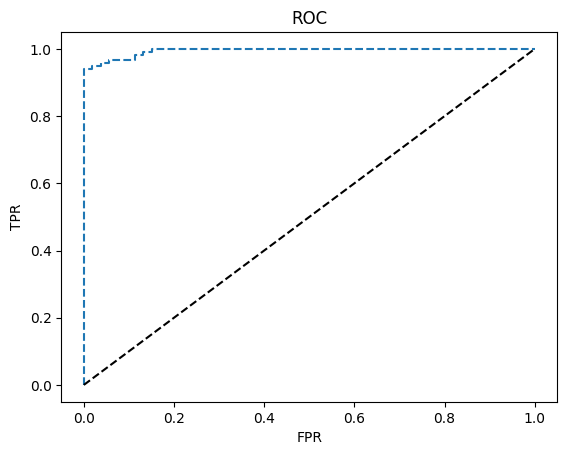

In [ ]:
plt.plot(fpr, tpr, '--', label="Support Vector Machine")     # 수정
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC CURVE')
plt.show()

### 9.5 gain and lift chart
- scikit-plot 설치 및 사용
- https://scikit-plot.readthedocs.io/en/stable/metrics.html
- pip install scikit-plot

In [ ]:
pip install scikit-plot

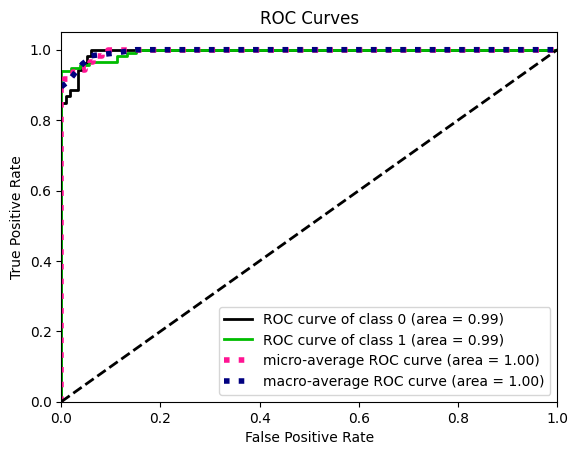

In [ ]:
# ROC_ACU Cruve
import scikitplot as skplt
skplt.metrics.plot_roc(y_test,
                       best_clf.predict_proba(X_test))
plt.show()

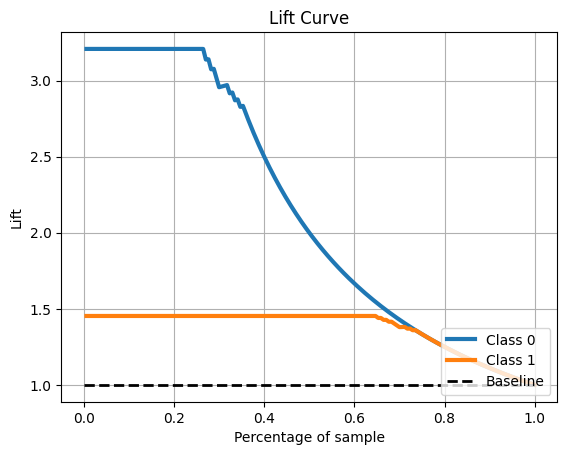

In [ ]:
# lift Chart
skplt.metrics.plot_lift_curve(y_test,
                              best_clf.predict_proba(X_test))
plt.show()

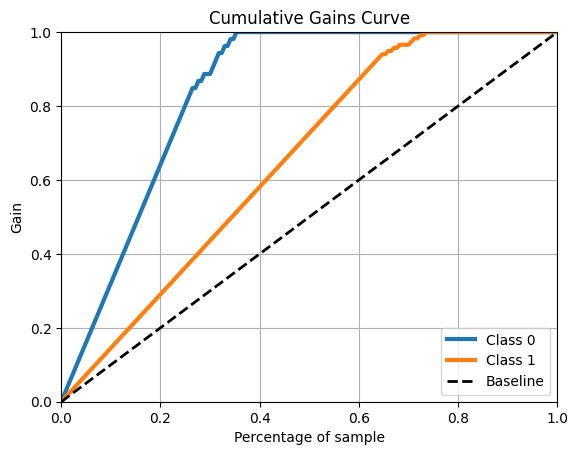

In [ ]:
# gain Chart
skplt.metrics.plot_cumulative_gain(y_test,
                                   best_clf.predict_proba(X_test))
plt.show()